<div style = "background-color:#1F3864; padding:25px; border-radius:8px;">
<h1 style="color:white; text-align:center; margin:0;"> Playground Series S6E9 — EV Purchase Prediction: Exploratory Data Analysis </h1>
<p style="color:#D9E2F3; text-align:center; margin-top:10px; font-size:15px;">
Exploring what drives EV purchase decisions — subsidy availability, range anxiety, 
income, and charging access — across 668K customers before building the 
classification model.
</p>
</div>

# Project Overview

This project tackles Kaggle's Playground Series Season 6, Episode 9: predicting whether
a consumer will purchase an electric vehicle (`Will_Buy_EV`), using a synthetic dataset
inspired by real EV adoption behavior and range-anxiety research.

**The data.** 668,665 training rows and 13 features covering demographics (`Age`,
`Gender`, `Annual_Income_USD`), driving habits (`Daily_Commute_km`, `Number_of_Cars_Owned`,
`Current_Car_Type`), charging infrastructure access (`Charging_Stations_Near_Home`,
`Charging_Stations_Near_Work`, `Home_Charging_Possible`), and psychological/policy factors
(`Environmental_Concern_Level`, `Range_Anxiety_Level`, `Subsidy_Available`). No missing
values anywhere.

**The target.** `Will_Buy_EV` is binary (Yes/No), with a real but moderate class
imbalance — about 17.5% Yes, 82.5% No. Submissions are scored on AUC-ROC, a ranking
metric, which matters for how this project is validated and evaluated throughout: the
goal is correctly ordering customers by purchase likelihood, not hitting a fixed
accuracy number, and accuracy itself would be a misleading metric to optimize for
given the imbalance.

**Why this problem matters practically.** Predicting EV purchase intent from
demographic, infrastructure, and policy features is directly useful for two real
decisions: which customers a manufacturer or dealer should target with EV marketing,
and — more interestingly, given what the EDA below finds — how much a subsidy program
or charging infrastructure investment actually moves the needle on adoption versus how
much intent is already baked into who a customer is.

**What this notebook covers.** Exploratory analysis of each feature's relationship to
the target (which surfaces two unusually dominant predictors early on), feature
engineering grounded in that analysis rather than guesswork, a comparison of
RandomForest, XGBoost, and LightGBM under stratified cross-validation, and an honest
account of what actually drives the model's predictions — including whether the
"heavy" engineered features add real lift beyond the two dominant raw columns, or
whether that's mostly carried by `Subsidy_Available` and `Range_Anxiety_Level` alone.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from statsmodels.tsa.stattools import adfuller

In [2]:
BLUE = "#2a78d6"
ORANGE = "#eb6834"
GRAY_MID = "#898781"
GRAY_LIGHT = "#e1e0d9"
RED = "#e34948"
GREEN = "#008300"
INK = "#0b0b0b"
SURFACE = "#fcfcfb"

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
plt.rcParams["axes.edgecolor"] = GRAY_LIGHT
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = GRAY_LIGHT
plt.rcParams["grid.linewidth"] = 0.6
plt.rcParams["font.family"] = "DejaVu Sans"

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">1. Load the Data </h2>
</div>

In [3]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
sample_submission = pd.read_csv("../data/raw/sample_submission.csv")

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">2. Review the Data Structure</h2>
</div>

In [4]:
train.head().T

,0,1,2,3,4
id,0,1,2,3,4
Age,66,38,26,66,54
Annual_Income_USD,92887.0,30000.0,94389.0,73580.0,57898.0
Daily_Commute_km,23.4,5.0,36.8,23.7,50.8
Number_of_Cars_Owned,2,1,1,2,1
Charging_Stations_Near_Home,3,2,8,6,2
Charging_Stations_Near_Work,7,2,15,9,3
Environmental_Concern_Level,1.0,4.0,5.0,3.0,3.0
Gender,Male,Male,Female,Male,Male
City_Type,Suburban,Rural,Urban,Suburban,Suburban


In [5]:
train.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.1 Checking the data types</h3>
</div>

In [6]:
for i , name in [("train",train),("test",test)]:
    print(f"{i} :\n {name.dtypes}")

train :
 id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       object
Current_Car_Type                object
Home_Charging_Possible          object
Subsidy_Available               object
Range_Anxiety_Level             object
Will_Buy_EV                     object
dtype: object
test :
 id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       o

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.2 Missing Values</h3>
</div>

In [7]:
for i , name in [("train",train),("test",test)]:
    missing = name.isna().sum().sum()
    print(missing)

0
0


<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.3 Outliers</h3>
</div>

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103210,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


## 2. Review the Data Structure

668,665 rows and 15 columns: `id`, 13 features, and the target `Will_Buy_EV`.

**Dtypes**
- int64: `Age`, `Number_of_Cars_Owned`, `Charging_Stations_Near_Home`, `Charging_Stations_Near_Work`
- float64: `Annual_Income_USD`, `Daily_Commute_km`, `Environmental_Concern_Level`
- object: `Gender`, `City_Type`, `Current_Car_Type`, `Home_Charging_Possible`, `Subsidy_Available`, `Range_Anxiety_Level`, `Will_Buy_EV`

No missing values.

**Ranges** (from `describe()`): Age 25–69, Annual_Income_USD 30,000–188,549, Daily_Commute_km 5.0–98.7, Number_of_Cars_Owned 1–4, Charging_Stations_Near_Home 0–14, Charging_Stations_Near_Work 0–19, Environmental_Concern_Level 1–5. The income and commute minimums look like generator floors rather than real outliers.

Target is imbalanced: ~17.5% Yes / 82.5% No.

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">3. Explanatory Data Analysis(EDA)</h2>
</div>

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.1 Statistical analysis</h3>
</div>

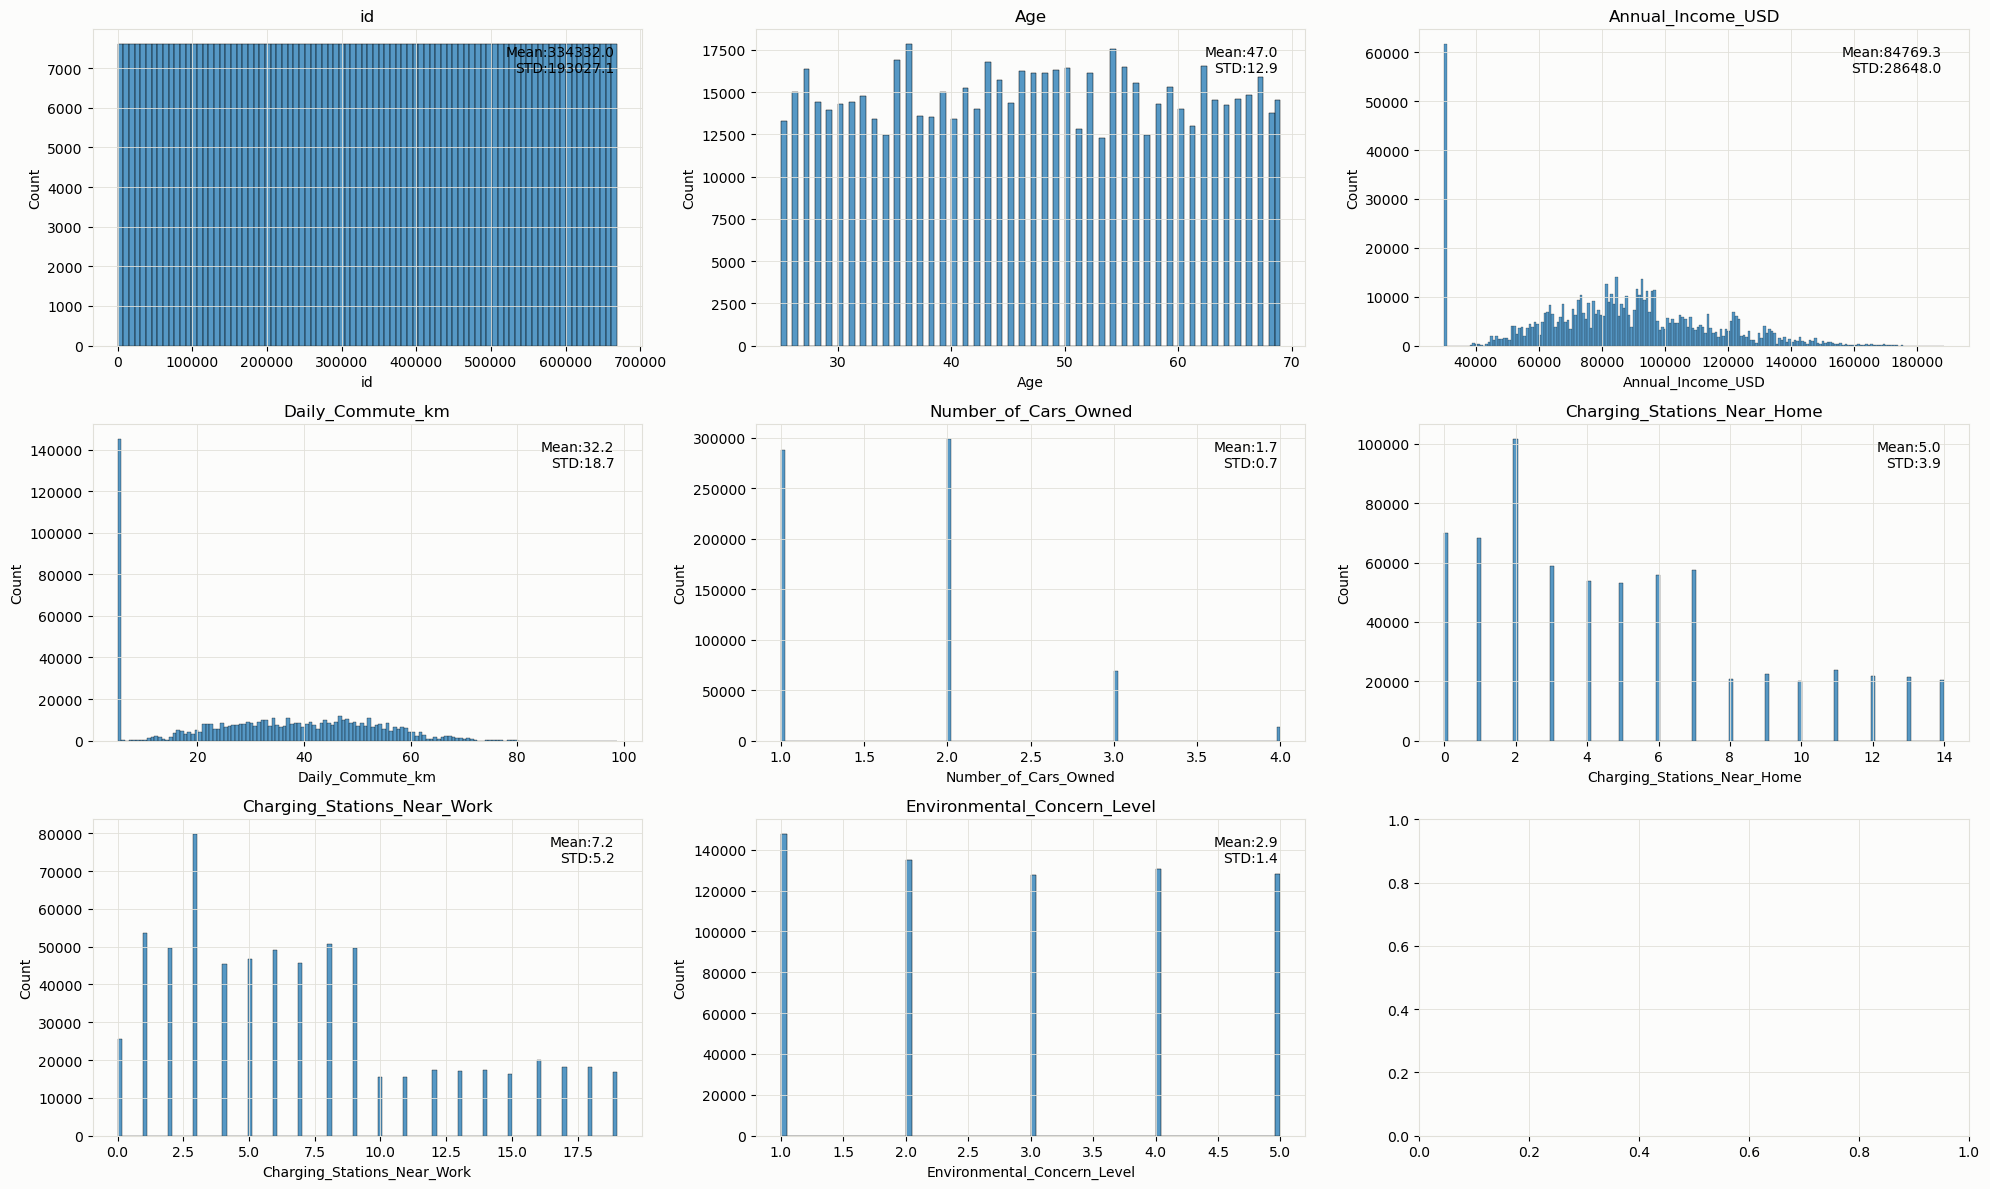

In [24]:
fig,ax = plt.subplots(3,3,figsize= (20,12))
ax= ax.flatten()

numeric = train.select_dtypes(include = "number").columns.tolist()
for i , name in enumerate(numeric):
    sns.histplot(data=train, x=name, ax=ax[i])
    ax[i].set_title(name)
    mean = train[name].mean()
    std = train[name].std()
    ax[i].text(0.95, 0.95, f"Mean:{mean:.1f}\nSTD:{std:.1f}",
           transform=ax[i].transAxes,
           ha="right", va="top")

plt.savefig("../charts/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 3.1 Numeric Feature Distributions

`id` is a row identifier, uniformly spread — not a feature, should be dropped before modeling.

**Age**: roughly uniform across 25–69, no skew.

**Annual_Income_USD**: sharp spike at the 30,000 floor, then right-skewed tail out to ~188K — confirms the generator-imposed minimum flagged earlier.

**Daily_Commute_km**: same pattern — spike at the 5.0 floor, then right-skewed tail to ~100km.

**Number_of_Cars_Owned**: discrete (1–4), heavily concentrated at 1 and 2, few at 3, rare at 4.

**Charging_Stations_Near_Home / Near_Work**: multimodal, no clean distribution shape — likely reflects distinct city/region tiers rather than random noise.

**Environmental_Concern_Level**: discrete 1–5, fairly evenly spread with a slight lean toward the low end.

Overall: two floor artifacts (income, commute) worth noting but not treating as outliers, and several genuinely discrete/multimodal features that behave more like categoricals than continuous variables.

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.2 Correlation analysis</h3>
</div>

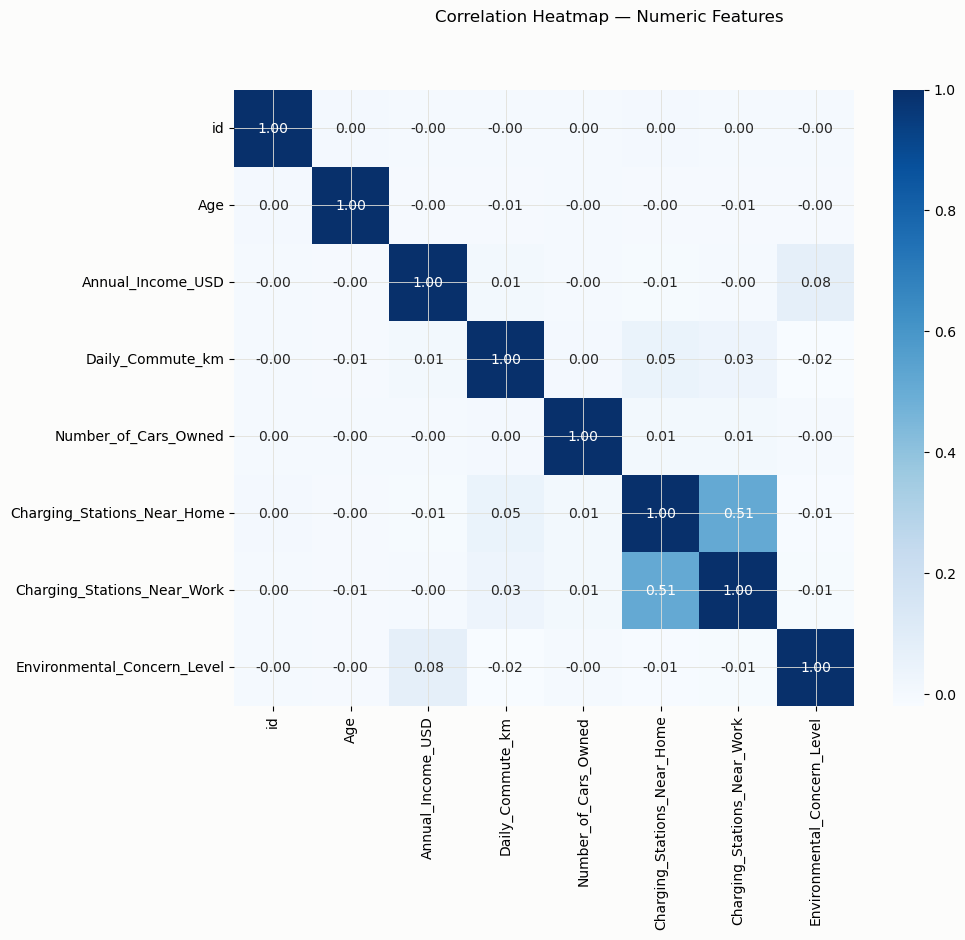

In [39]:
plt.figure(figsize=(10, 8))
corr = train.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.suptitle("Correlation Heatmap — Numeric Features")
plt.savefig("../charts/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.2 Correlation Analysis

Almost all numeric features are uncorrelated with each other — the only notable relationship is **Charging_Stations_Near_Home ↔ Charging_Stations_Near_Work (0.51)**, a moderate positive correlation (areas with more stations near home tend to also have more near work — likely reflects general regional charging infrastructure density).

No multicollinearity concerns for modeling — everything else is near zero. Note this heatmap only covers numeric features; the strongest predictors identified so far (`Subsidy_Available`, `Range_Anxiety_Level`) are categorical and won't show up here.

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.3 Data Vizualization analysis</h3>
</div>

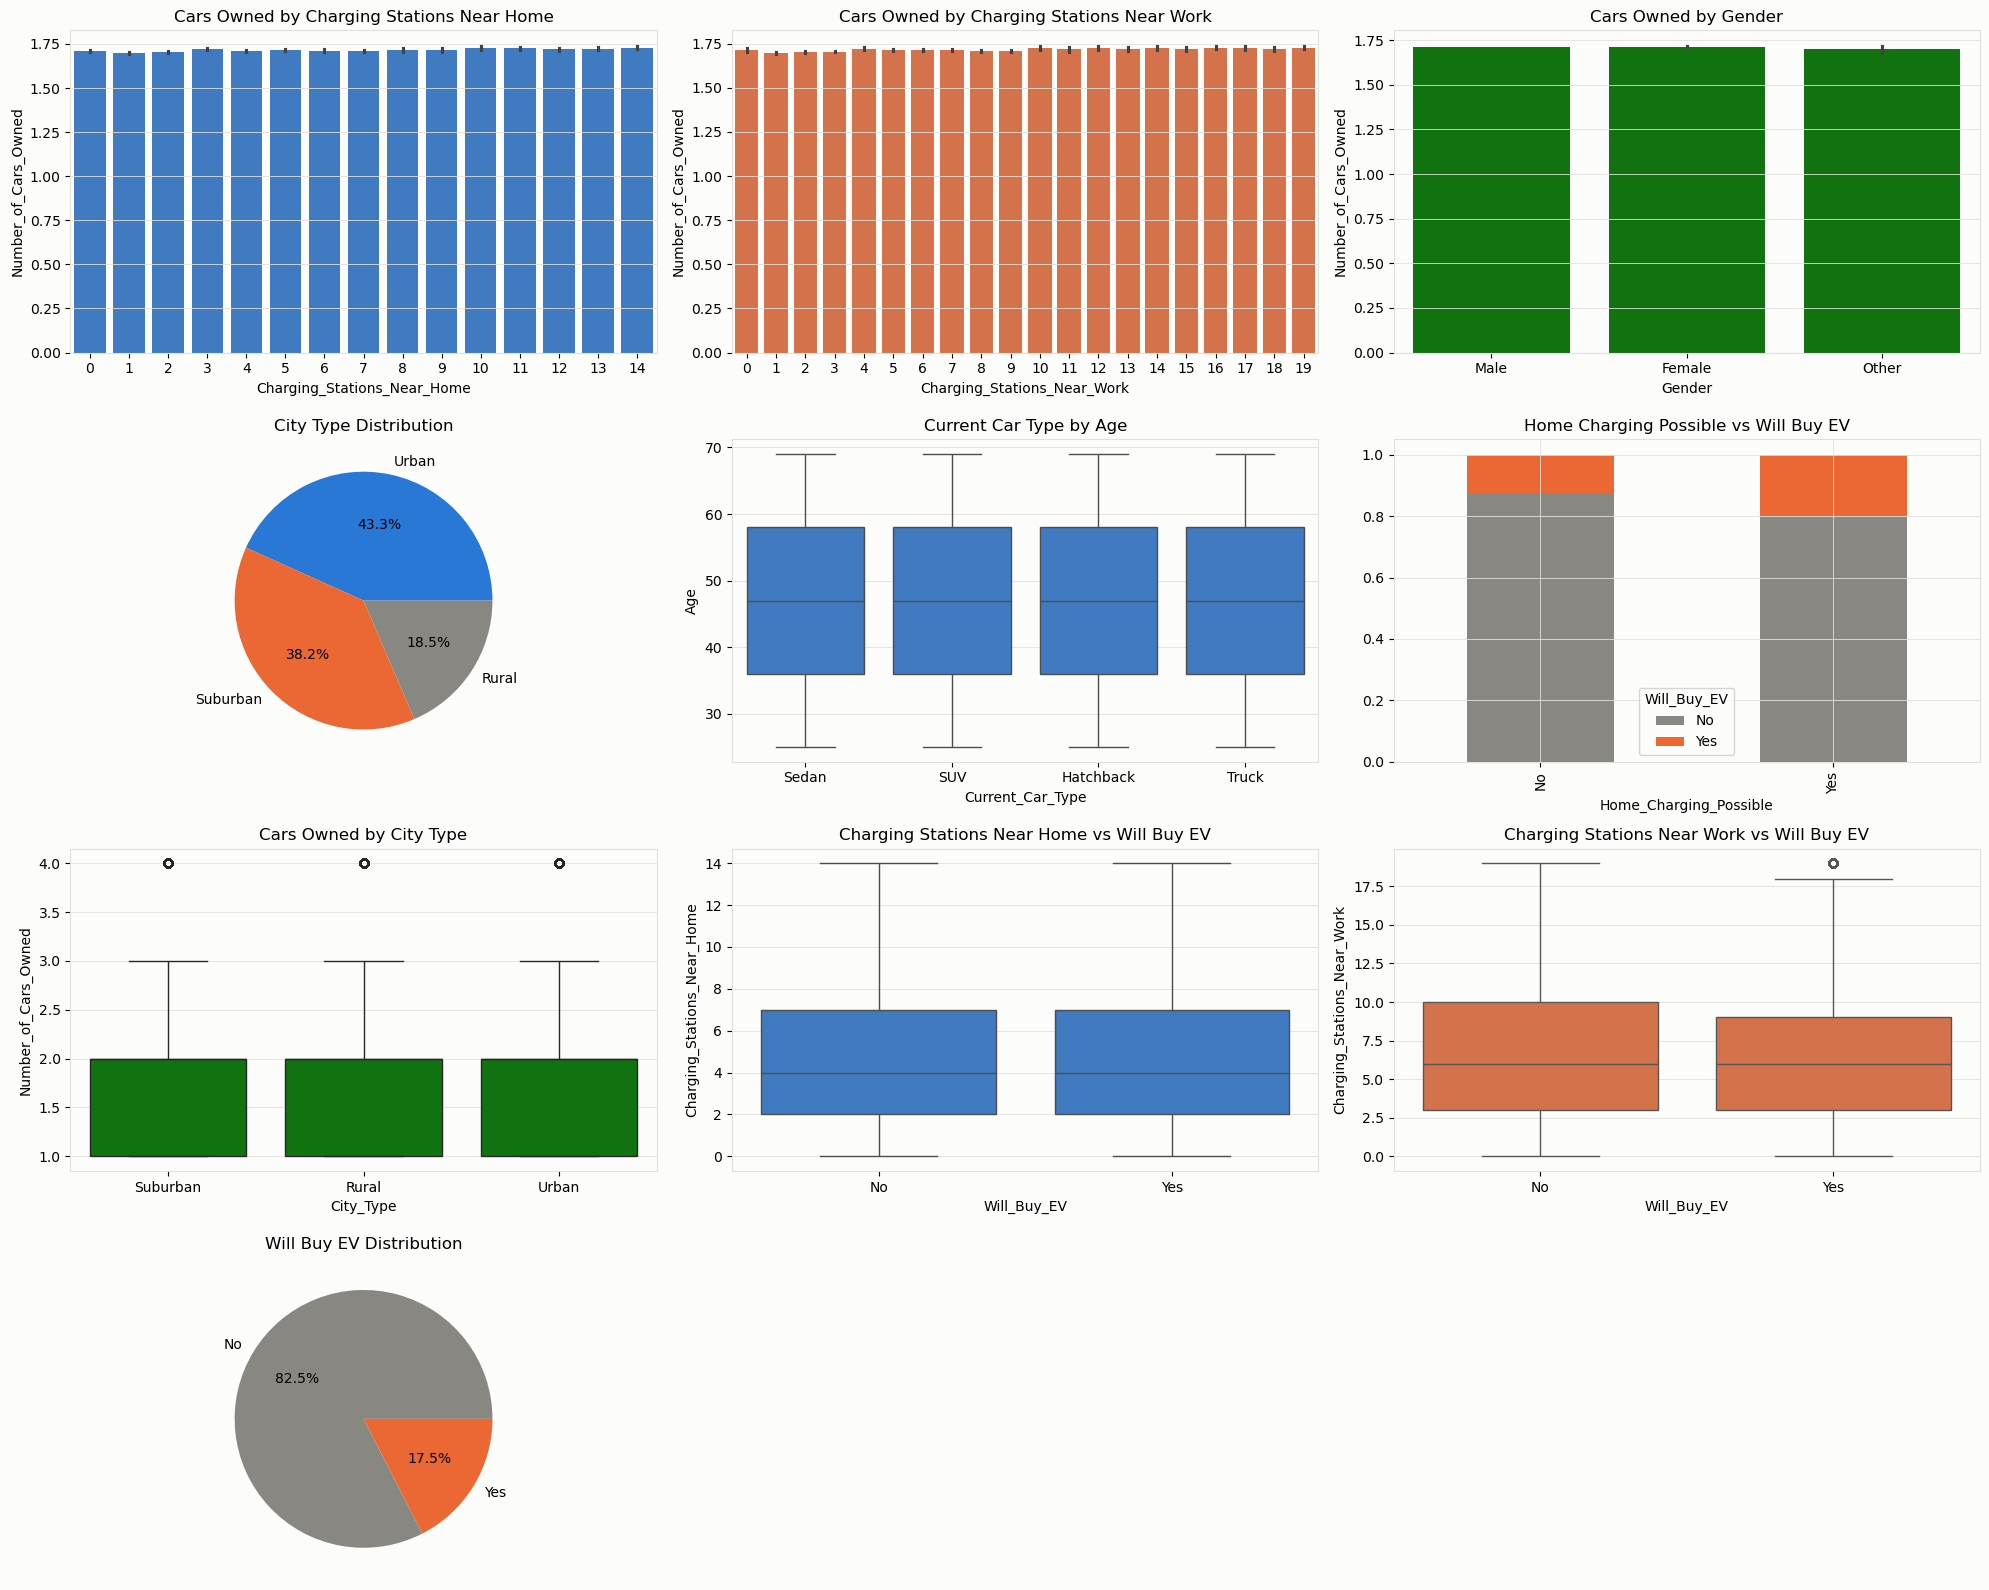

In [38]:
fig, ax = plt.subplots(4, 3, figsize=(20, 16))
ax = ax.flatten()

# 1. Number of cars owned by charging stations near home
sns.barplot(data=train, x="Charging_Stations_Near_Home", y="Number_of_Cars_Owned", ax=ax[0], color=BLUE)
ax[0].set_title("Cars Owned by Charging Stations Near Home")

# 2. Number of cars owned by charging stations near work
sns.barplot(data=train, x="Charging_Stations_Near_Work", y="Number_of_Cars_Owned", ax=ax[1], color=ORANGE)
ax[1].set_title("Cars Owned by Charging Stations Near Work")

# 3. Number of cars owned by gender
sns.barplot(data=train, x="Gender", y="Number_of_Cars_Owned", ax=ax[2], color=GREEN)
ax[2].set_title("Cars Owned by Gender")

# 4. City type pie chart
train["City_Type"].value_counts().plot.pie(ax=ax[3], autopct="%1.1f%%",
                                            colors=[BLUE, ORANGE, GRAY_MID])
ax[3].set_ylabel("")
ax[3].set_title("City Type Distribution")

# 5. Current car type by age
sns.boxplot(data=train, x="Current_Car_Type", y="Age", ax=ax[4], color=BLUE)
ax[4].set_title("Current Car Type by Age")

# 6. Home charging possible vs Will_Buy_EV
pd.crosstab(train["Home_Charging_Possible"], train["Will_Buy_EV"], normalize="index").plot(
    kind="bar", stacked=True, ax=ax[5], color=[GRAY_MID, ORANGE])
ax[5].set_title("Home Charging Possible vs Will Buy EV")

# 7. Number of cars by city type
sns.boxplot(data=train, x="City_Type", y="Number_of_Cars_Owned", ax=ax[6], color=GREEN)
ax[6].set_title("Cars Owned by City Type")

# 8. Charging stations near home vs Will_Buy_EV
sns.boxplot(data=train, x="Will_Buy_EV", y="Charging_Stations_Near_Home", ax=ax[7], color=BLUE)
ax[7].set_title("Charging Stations Near Home vs Will Buy EV")

# 9. Charging stations near work vs Will_Buy_EV
sns.boxplot(data=train, x="Will_Buy_EV", y="Charging_Stations_Near_Work", ax=ax[8], color=ORANGE)
ax[8].set_title("Charging Stations Near Work vs Will Buy EV")

# 10. Will_Buy_EV pie chart
train["Will_Buy_EV"].value_counts().plot.pie(ax=ax[9], autopct="%1.1f%%",
                                              colors=[GRAY_MID, ORANGE])
ax[9].set_ylabel("")
ax[9].set_title("Will Buy EV Distribution")

# hide unused subplots (11, 12)
ax[10].axis("off")
ax[11].axis("off")

plt.tight_layout()
plt.savefig("../charts/relationship_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.3 Feature Relationship Analysis

Number_of_Cars_Owned is flat everywhere — charging stations near home/work, gender — confirming it's not a useful predictor.

City_Type: Urban 43.3%, Suburban 38.2%, Rural 18.5%.

Current_Car_Type shows no difference by age — identical median (~47) across Sedan, SUV, Hatchback, Truck.

**Home_Charging_Possible vs Will_Buy_EV** is the strongest signal here: the Yes group has a visibly higher EV purchase rate than No.

Cars owned by City_Type: nearly identical across Suburban, Rural, Urban.

**Charging_Stations_Near_Home / Near_Work vs Will_Buy_EV**: distributions barely differ between buyers and non-buyers — weaker signal than the raw groupby numbers suggested earlier, worth treating as a secondary feature rather than a strong one.

Target confirmed imbalanced: 82.5% No / 17.5% Yes.

Overall: Home_Charging_Possible joins Subsidy_Available and Range_Anxiety_Level as a meaningful predictor; charging-station counts and cars-owned look weak on their own but may still contribute via interaction features.